# 2. Exploratory Data Analysis

## Dataset Overview

### Data Source
For this analysis the result of data preparation dataframe will be used. It already has all the basic corrections done.

### Dataset Description

**Table: rest_data**

| Column | Description |
|--------|-------------|
| `id` |  Restaurant establishment unique id |
| `object_name` |  Restaurant establishment name |
| `address` | Full address of the establishment |
| `chain` | Whether the establishment is part of a chain (TRUE/FALSE) |
| `object_type` | Type of establishment (e.g., restaurant, cafe, bar) |
| `number` | Number of seats in the establishment |


## Objectives

1. Investigate the proportions of different establishment types
2. Investigate chain vs non-chain proportions
3. Identify which establishment type is typical for chains
4. Analyze what characterizes chains: many establishments with few seats or few establishments with many seats
5. Determine the average number of seats per establishment type
6. Extract street names from the address column
7. Find the top 10 streets with the most restaurants
8. Find the number of streets with only one restaurant
9. Analyze the seat distribution for streets with many restaurants
10. Draw overall conclusions and recommendations

In [188]:
# Importing necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [189]:
# Reading cleaned data
rest_data = pd.read_csv("../data/rest_data_cleaned.csv",
                        dtype={"object_type": "category"})

In [190]:
# Checking df informations
rest_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   id           9648 non-null   int64   
 1   object_name  9648 non-null   str     
 2   address      9648 non-null   str     
 3   chain        9648 non-null   bool    
 4   object_type  9648 non-null   category
 5   number       9648 non-null   int64   
dtypes: bool(1), category(1), int64(2), str(2)
memory usage: 320.7 KB


## 2.1 Establishment type proportions

In [191]:
# Getting total number of establishments
total_estab = rest_data['object_type'].count()

In [192]:
# Get establishments count by type
estab_types = rest_data['object_type'].value_counts().reset_index()

In [193]:
# Adding proportion column
estab_types['proportion'] = estab_types['count'] / total_estab * 100

In [194]:
# Checking results
estab_types

,object_type,count,proportion
0,Restaurant,7253,75.176202
1,Fast Food,1066,11.048922
2,Cafe,435,4.508706
3,Pizza,319,3.306385
4,Bar,292,3.026534
5,Bakery,283,2.933250


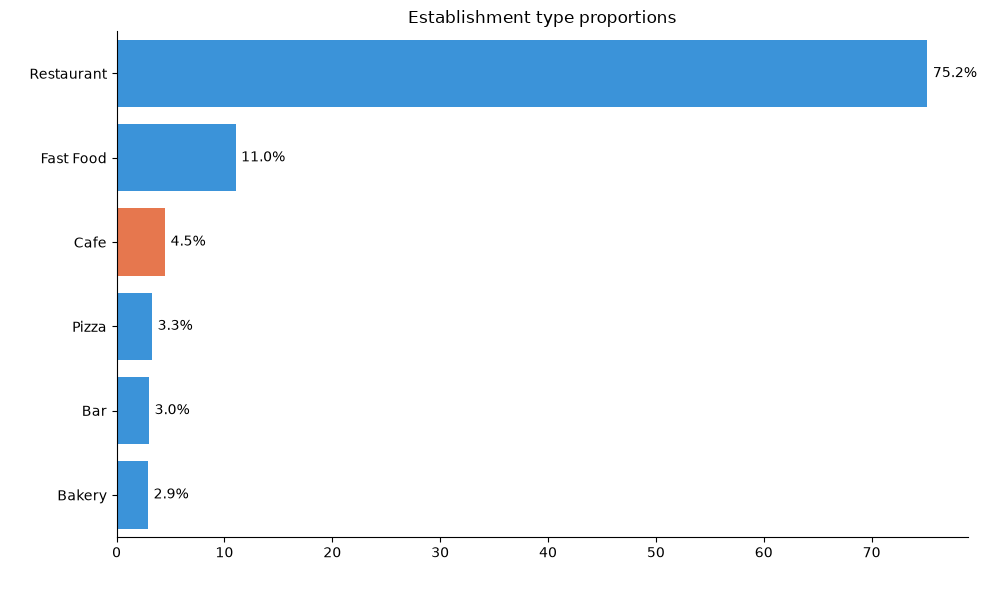

In [195]:
# Plotting H barchart
plt.figure(figsize=(10, 6))

colors = {t: ('#FF6B35' if t == 'Cafe' else '#2196F3')
          for t in estab_types['object_type']}

ax = sns.barplot(y="object_type", x="proportion",
                 data=estab_types, order=estab_types['object_type'],
                 palette=colors, hue='object_type', legend=False, dodge=False)

for i, val in enumerate(estab_types['proportion']):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center')


ax.set_title('Establishment type proportions')
ax.set_xlabel(' ')
ax.set_ylabel(' ')

sns.despine()
plt.tight_layout()
plt.show()

### Interpretation

The bar chart reveals a **highly concentrated market** dominated by traditional restaurants:

- **Restaurants** account for **75.2%** of all establishments, making them the overwhelming majority
- **Fast Food** follows distantly with **11.0%**, the only other significant category
- Other types (**Cafes, Pizza, Bars, Bakeries**) are niche segments, each representing less than 5%

**Key Insight:** The LA market is heavily skewed towards full-service restaurants. The limited presence of cafes (4.5%) could indicate a market gap for a casual dining concept like a robot-staffed cafeteria.

## 2.2 Establishment chain (or not) proportions

In [196]:
# Get chain or not chain count
chain_stats = rest_data['chain'].value_counts().reset_index()

In [197]:
# Calculating proportions
chain_stats['chain_proportion'] = chain_stats['count'] / total_estab * 100

In [198]:
chain_stats.columns = ['is_chain', 'total', 'chain_proportion']

In [199]:
chain_stats['is_chain'] = chain_stats['is_chain'].replace(
    {False: 'Non-Chain', True: 'Chain'})

In [200]:
# Checking results
chain_stats

,is_chain,total,chain_proportion
0,Non-Chain,5972,61.898839
1,Chain,3676,38.101161


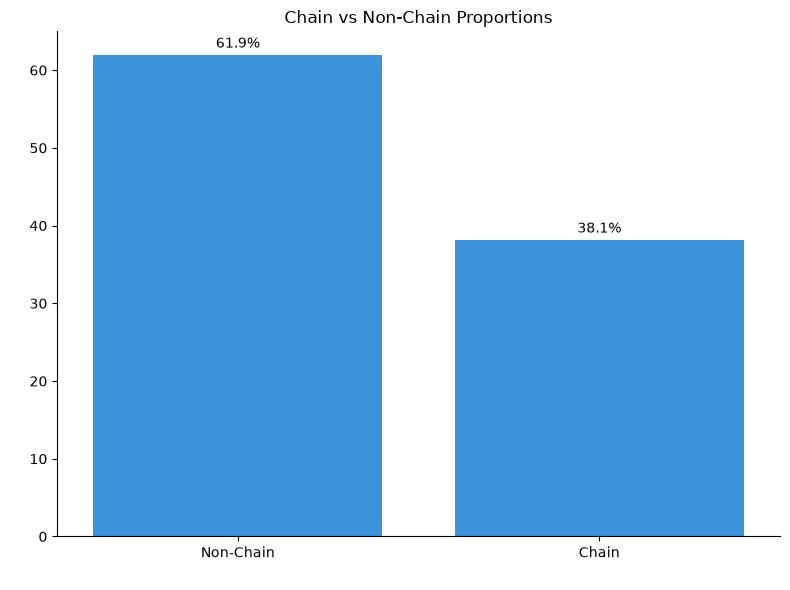

In [201]:
plt.figure(figsize=(8, 6))


ax = sns.barplot(x="is_chain", y="chain_proportion",
                 data=chain_stats, color="#2196F3")

for i, val in enumerate(chain_stats['chain_proportion']):
    ax.text(i, val + 1, f'{val:.1f}%', ha='center')


ax.set_title('Chain vs Non-Chain Proportions')
ax.set_xlabel(' ')
ax.set_ylabel(' ')

sns.despine()
plt.tight_layout()
plt.show()

### Interpretation

Nearly **62% of establishments are independent**, while **38% belong to chains** — a significant share.

**Key Insight:** The strong chain presence (38%) shows that scalable concepts work well in LA, which is a good sign for a robot-staffed cafeteria that could easily replicate across locations.

## 2.3 Chain percentage by establishment type

In [202]:
# Calculate chain percentage for each establishment type
chain_by_type = rest_data.groupby('object_type')['chain'].mean() * 100
chain_by_type = chain_by_type.sort_values(ascending=False).reset_index()
chain_by_type.columns = ['object_type', 'chain_pct']
chain_by_type

,object_type,chain_pct
0,Bakery,100.000000
1,Cafe,61.149425
2,Fast Food,56.754221
3,Pizza,47.962382
4,Restaurant,31.600717
5,Bar,26.369863


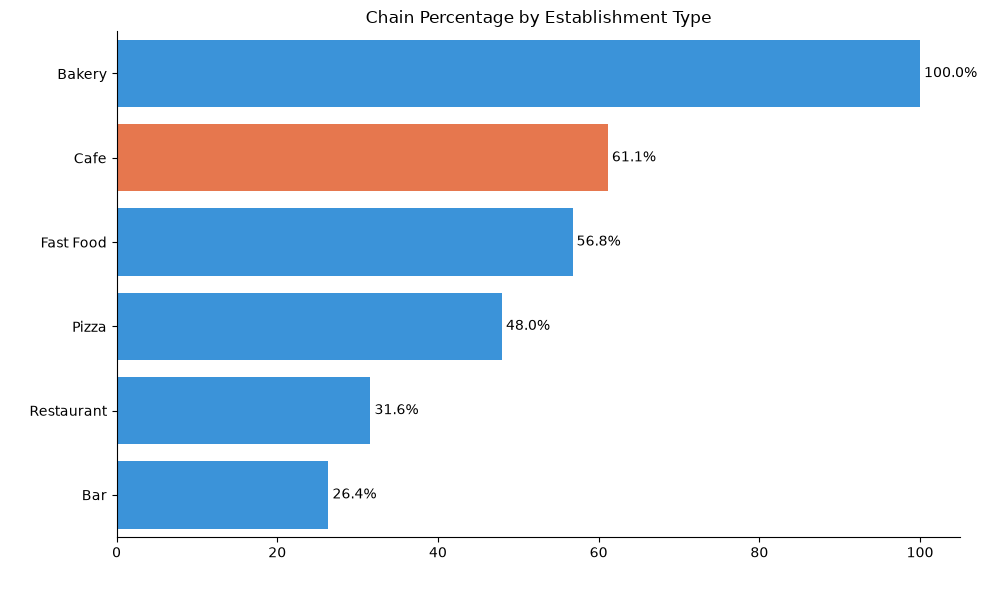

In [203]:
# Plotting chain percentage by establishment type
plt.figure(figsize=(10, 6))

colors = {t: ('#FF6B35' if t == 'Cafe' else '#2196F3')
          for t in chain_by_type['object_type']}

ax = sns.barplot(y="object_type", x="chain_pct",
                 data=chain_by_type, order=chain_by_type['object_type'],
                 palette=colors, hue='object_type', legend=False, dodge=False)

for i, val in enumerate(chain_by_type['chain_pct']):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center')

ax.set_title('Chain Percentage by Establishment Type')
ax.set_xlabel(' ')
ax.set_ylabel(' ')

sns.despine()
plt.tight_layout()
plt.show()

### Interpretation

The chart shows the percentage of each establishment type that belongs to a chain:

- **Bakery** stands out with **100%** being chains — every bakery in the dataset is part of a chain
- **Cafe (61.1%)** and **Fast Food (56.8%)** also have a strong chain presence, meaning these types scale well as chain businesses
- **Restaurants (31.6%)** and **Bars (26.4%)** are the least chain-oriented, tending to be more independent

**Key Insight:** Cafes have a high chain rate (61%), which shows that the cafe model is well suited for chain operations. This is a positive sign for a robot-staffed cafeteria concept, as the market already supports scalable cafe chains.

## 2.4 What characterizes chains?

In [204]:
# Compare seat count distribution: chain vs non-chain
rest_data.groupby('chain')['number'].describe()

,count,mean,std,min,25%,50%,75%,max
chain,,,,,,,,
False,5972.0,46.171467,49.875746,1.0,14.0,28.0,47.0,229.0
True,3676.0,39.694233,43.437212,1.0,13.0,25.0,44.0,229.0


In [205]:
# Median seats: chain vs non-chain
median_seats = rest_data.groupby('chain')['number'].median().reset_index()
median_seats['chain'] = median_seats['chain'].replace(
    {False: 'Non-Chain', True: 'Chain'})
median_seats.columns = ['is_chain', 'median_seats']

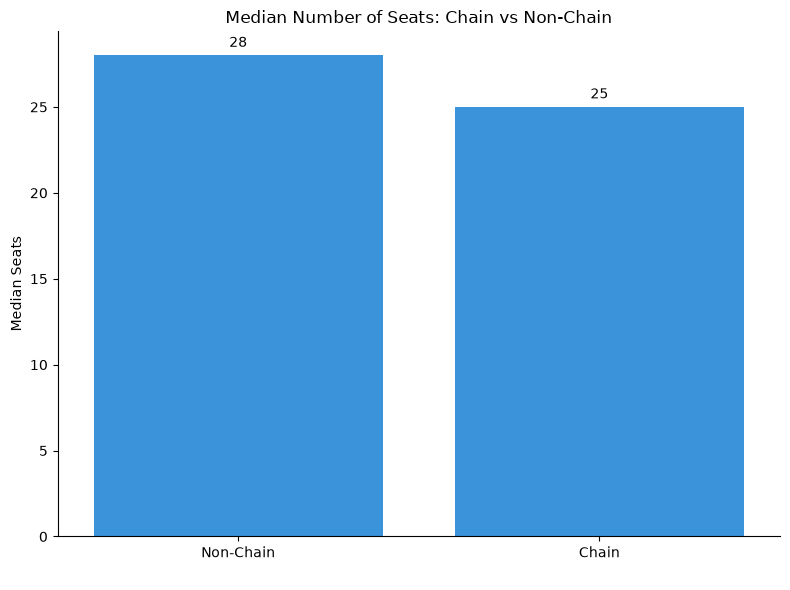

In [206]:
# Plotting chart
plt.figure(figsize=(8, 6))

ax = sns.barplot(x="is_chain", y="median_seats", data=median_seats,
                 color="#2196F3")

for i, val in enumerate(median_seats['median_seats']):
    ax.text(i, val + 0.5, f'{val:.0f}', ha='center')

ax.set_title('Median Number of Seats: Chain vs Non-Chain')
ax.set_xlabel(' ')
ax.set_ylabel('Median Seats')

sns.despine()
plt.tight_layout()
plt.show()

### Interpretation

Looking at the `describe()` results and the chart, chains have a **median of 25 seats** compared to **28 seats** for non-chains — a modest difference, but consistent with chains favoring smaller establishments. At the same time, there are **3676 chain establishments** vs **5972 non-chain**.

**Key Insight:** Chains tend to lean towards **many establishments with a smaller number of seats**, rather than a few large ones. This is consistent with chain models that focus on replicating smaller, standardized locations across multiple sites.

## 2.5 Average seats per type

In [207]:
# Calculating average seats per establishment type
avg_seats_type = rest_data.groupby(
    'object_type')['number'].mean().reset_index()

In [208]:
# Sorting values per seats number
avg_seats_type.sort_values('number', ascending=False, inplace=True)

# Change columns names
avg_seats_type.columns = ['type', 'avg_seats']

# Converting to int numbers
avg_seats_type['avg_seats'] = avg_seats_type['avg_seats'].round(0).astype(int)

In [209]:
# Checking results
avg_seats_type

,type,avg_seats
5,Restaurant,48
1,Bar,45
3,Fast Food,32
4,Pizza,29
2,Cafe,25
0,Bakery,22


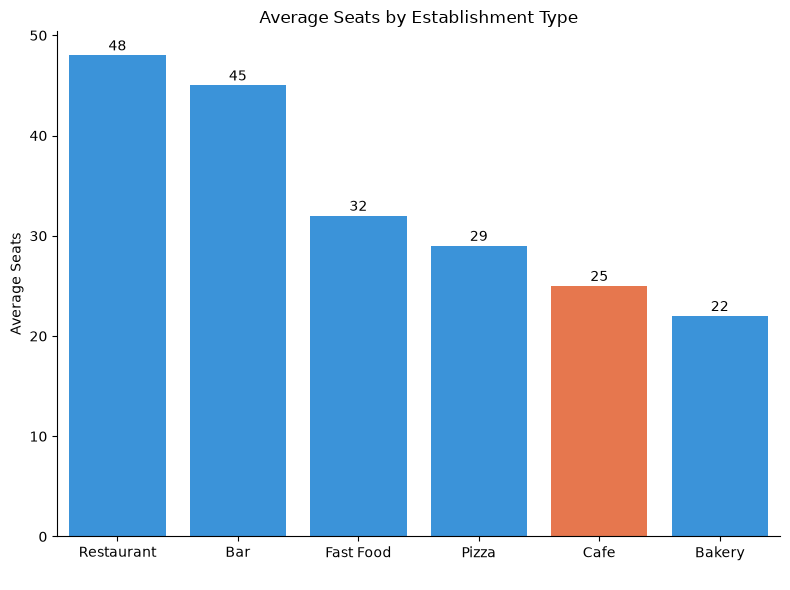

In [210]:
# Plotting barchart to compare average seats
plt.figure(figsize=(8, 6))

colors = {t: ('#FF6B35' if t == 'Cafe' else '#2196F3')
          for t in avg_seats_type['type']}

ax = sns.barplot(x='type', y='avg_seats', data=avg_seats_type,
                 order=avg_seats_type['type'], palette=colors,
                 hue='type', legend=False, dodge=False)

for i, val in enumerate(avg_seats_type['avg_seats']):
    ax.text(i, val + 0.5, f'{val:.0f}', ha='center')

ax.set_title('Average Seats by Establishment Type')
ax.set_xlabel(' ')
ax.set_ylabel('Average Seats')

sns.despine()
plt.tight_layout()
plt.show()

### Interpretation

Restaurants (48) and Bars (45) have the highest average seat counts, while Cafes (25) and Bakeries (22) are at the top bottom.

**Key Insight:** Cafe's smaller average seat count means lower space requirements and setup costs. Combined with its high chain rate (61%, seen in section 2.3), this confirms the cafe format is well suited for compact, replicable locations — a strong fit for a robot-staffed cafeteria aiming to scale efficiently.


## 2.6 Extracting street name

In [211]:
rest_data['street'] = (
    rest_data['address']
    # remove leading building number
    .str.replace(r'^\d+\s*', '', regex=True)
    # remove suite/unit suffix
    .str.replace(r'\s+(STE|SUITE|UNIT|#)\s*\w*$', '', regex=True)
    # remove trailing standalone number
    .str.replace(r'\s+\d+$', '', regex=True)
    .str.strip()
)

In [212]:
# Confirming update
rest_data

,id,object_name,address,chain,object_type,number,street
0,11786,HABITAT COFFEE SHOP,3708 N EAGLE ROCK BLVD,False,Cafe,26,N EAGLE ROCK BLVD
1,11787,REILLY'S,100 WORLD WAY 120,False,Restaurant,9,WORLD WAY
2,11788,STREET CHURROS,6801 HOLLYWOOD BLVD 253,False,Fast Food,20,HOLLYWOOD BLVD
3,11789,TRINITI ECHO PARK,1814 W SUNSET BLVD,False,Restaurant,22,W SUNSET BLVD
4,11790,POLLEN,2100 ECHO PARK AVE,False,Restaurant,20,ECHO PARK AVE
...,...,...,...,...,...,...,...
9643,21432,HALL OF JUSTICE,217 W TEMPLE AVE,False,Restaurant,122,W TEMPLE AVE
9644,21433,FIN-MELROSE,5750 MELROSE AVE,False,Restaurant,93,MELROSE AVE
9645,21434,JUICY WINGZ,6741 HOLLYWOOD BLVD,True,Fast Food,15,HOLLYWOOD BLVD
9646,21435,MEDIDATE COFFEE,548 S SPRING ST STE 100,False,Cafe,6,S SPRING ST


## 2.7 Top 10 streets with more establishments

In [213]:
# Group by street: count establishments and total seats
streets_stats = rest_data.groupby('street').agg(
    {'object_type': 'count', 'number': 'sum'}).reset_index()

In [214]:
# Sorting streets by establishment count
streets_stats.sort_values('object_type', ascending=False, inplace=True)

In [215]:
# Getting top 10 streets
top_10 = streets_stats.head(10).reset_index(drop=True)

In [216]:
# Checking results
top_10

,street,object_type,number
0,W SUNSET BLVD,329,16433
1,W PICO BLVD,322,12888
2,WILSHIRE BLVD,312,17054
3,SANTA MONICA BLVD,230,8264
4,S WESTERN AVE,222,9242
5,HOLLYWOOD BLVD,218,11939
6,W OLYMPIC BLVD,205,10664
7,S FIGUEROA ST,199,9521
8,S VERMONT AVE,192,8416
9,W 3RD ST,190,7599


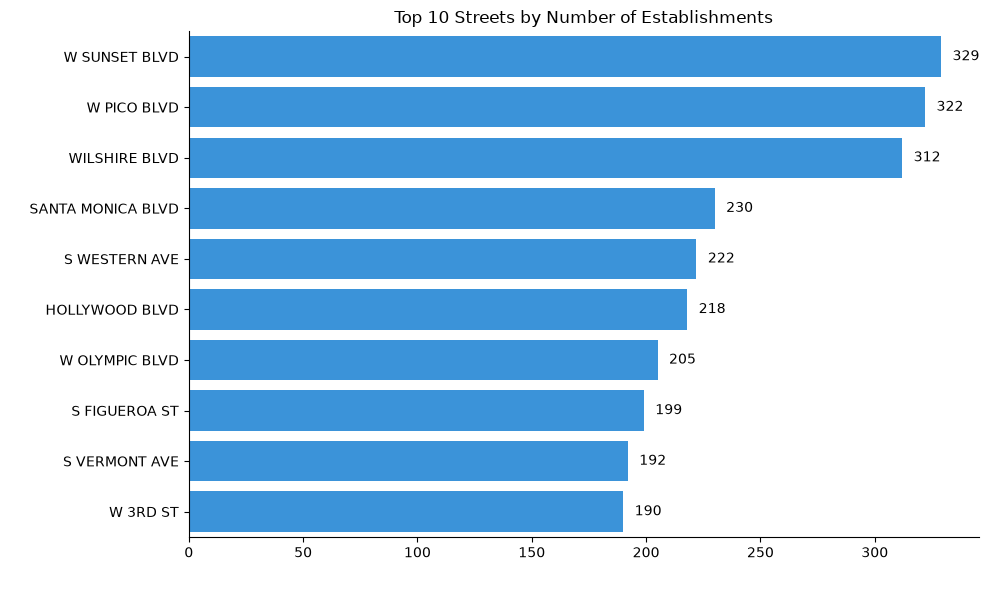

In [217]:
# Plotting top 10 streets with most establishments
plt.figure(figsize=(10, 6))

ax = sns.barplot(y='street', x='object_type', data=top_10,
                 order=top_10['street'], color="#2196F3")

for i, val in enumerate(top_10['object_type']):
    ax.text(val + 5, i, f'{val}', va='center')

ax.set_title('Top 10 Streets by Number of Establishments')
ax.set_xlabel(' ')
ax.set_ylabel(' ')

sns.despine()
plt.tight_layout()
plt.show()

### Interpretation

The top street is **W Sunset Blvd** with **329 establishments**, closely followed by **W Pico Blvd (322)** and **Wilshire Blvd (312)**. The rest of the top 10 streets have between 190 and 230 establishments.

**Key Insight:** These streets are major LA avenues with heavy restaurant concentration, meaning high competition. This is useful information when deciding where to open a new establishment.

## 2.8 Street with only 1 establishment

In [218]:
# Counting streets with only 1 establishment
streets_one_rest = (streets_stats['object_type'] == 1).sum()
print(f'Number of streets with only 1 establishment: {streets_one_rest}')

Number of streets with only 1 establishment: 963


### Interpretation

There are **963 streets** with only one establishment, out of a total of **1490 unique streets** (from section 2.6) — meaning the majority of streets (about 65%) have just a single restaurant.

**Key Insight:** While a few major avenues are highly saturated (section 2.7), most streets in LA have low restaurant density. This suggests there are still many less competitive locations available for a new establishment.

## 2.9 Top 10 streets seats distribution

In [219]:
# Filter data to only the top 10 streets
top_10_data = rest_data[rest_data['street'].isin(top_10['street'])]

In [ ]:
# Plotting boxplot and violin plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.boxplot(y='street', x='number', data=top_10_data,
            order=top_10['street'], color="#2196F3",
            showfliers=False, ax=axes[0])
axes[0].set_title('Boxplot: Seats Distribution')
axes[0].set_xlabel('Number of Seats')
axes[0].set_ylabel(' ')

sns.violinplot(y='street', x='number', data=top_10_data,
               order=top_10['street'], color="#2196F3",
               cut=0, ax=axes[1])
axes[1].set_title('Violin Plot: Seats Distribution')
axes[1].set_xlabel('Number of Seats')
axes[1].set_ylabel(' ')

sns.despine()
plt.tight_layout()
plt.show()

### Interpretation

Looking at both charts, most of the top 10 streets follow a similar pattern: a **median around 25-35 seats**, with a **right-skewed distribution** — meaning there are many smaller establishments and a few larger ones pulling the tail to the right.

**Wilshire Blvd** and **Hollywood Blvd** stand out with higher medians and a wider spread, suggesting these streets tend to have larger establishments compared to the others.

**Key Insight:** Even on the busiest streets, smaller establishments (around 20-40 seats) are the most common. This reinforces that a compact format, like a robot-staffed cafeteria, fits well with what's already typical in these high-traffic locations.

## 2.10 General Conclusion and Recommendations

Based on the analysis above, opening a **cafe-type, robot-staffed cafeteria** in LA looks like a solid concept, for a few reasons:

- **Market gap:** Cafes represent only **4.5%** of all establishments (section 2.1), meaning the market is not saturated with this type, unlike Restaurants (75.2%) or Fast Food (11.0%).
- **Chain-friendly format:** Cafes have one of the highest chain rates among establishment types, **61.1%** (section 2.3). This shows that the cafe model is naturally suited to chain expansion — same branding, decor, staff uniforms, and marketing strategy can be replicated across locations.
- **Lower investment per location:** Cafes have one of the smallest average seat counts, **25 seats** (section 2.5), well below Restaurants (48) and Bars (45). Fewer seats generally means a smaller space and lower setup cost per establishment, making it easier to open multiple locations.
- **Chains favor this format:** Chains in general tend to have **more establishments with fewer seats** rather than few large ones (section 2.4) — consistent with a small, replicable cafe format.
- **Location strategy:** While a few streets (e.g., W Sunset Blvd, W Pico Blvd, Wilshire Blvd) are highly saturated with restaurants (section 2.7), the majority of streets (about 65%, section 2.8) have only one establishment, leaving room for less competitive locations.

**Recommendation:** A small-format cafe (around 20-30 seats) is the most appropriate type and size for this concept. Given the strong chain affinity already seen in the cafe segment, there is good potential to develop this cafeteria into a chain over time, replicating the same compact, standardized format across multiple LA locations.

**Limitations:** This analysis is based only on the current distribution of existing establishments (supply side) — it does not include demand, revenue, or foot traffic data. It also cannot directly answer whether success will hold once the novelty of robot waiters fades, since that depends on factors outside this dataset. However, betting on a replicable, low-cost chain model (rather than a single large location) helps reduce that risk, since the business would not depend on one location's novelty appeal to sustain itself.